In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from tqdm import tqdm
import os
import pickle
from scipy import stats
from statsmodels.stats.multitest import multipletests

import helper

/gpfs1/home/c/p/cpetak/Variability_of_Evolvability/helper.py:106: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  next_step = windows.dot(grn)
/gpfs1/home/c/p/cpetak/Variability_of_Evolvability/helper.py:129: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  next_step = gene_vals.dot(internal_grn)


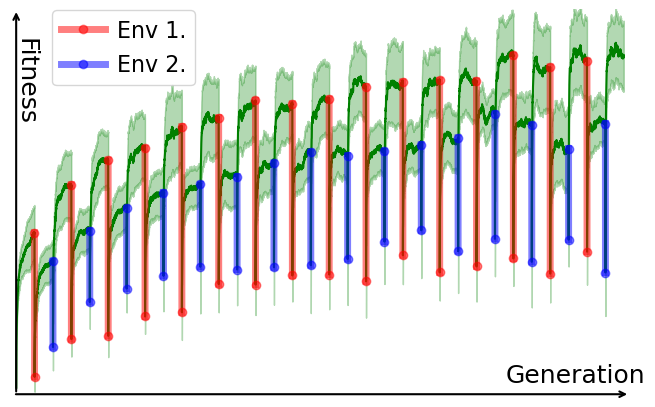

In [7]:
#Example line plot to illustrate methods

seed_intss = [[69904,149796],[4147842,1238860],[1677032,1410667],[2607162,1754028],[286634,159689],[2961036,153075],[3430997,2634107]]
metric="avefits"
season_len = 300
num_reps=15
root="~/CA_GRN_results/detailed_save/"#extra_inputs/"
root="~/CA_GRN_results/non_detailed_save/"#extra_inputs/"
id_start=0
seed_ints = seed_intss[1]

num_gens = 10_000

rules = [30] #[22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]

my_type = "drops" #"mins" or "drops" depending on which figure you want to make

s1drops=[]
s2drops=[]
fitdeltas1=[]
fitdeltas2=[]
for rule in rules:
    fig, ax=plt.subplots(nrows=1,ncols=1, figsize=(8, 5),sharex=True) #sharey=True)
    all_maxs=helper.get_fits([rule,rule], seed_ints, metric, root, season_len, num_reps, id_start, extrapolate=True)
    all_maxs=np.array(all_maxs)

    labels=["Variable","Static 1","Static 2"]
    colors = ["green", "lightblue", "orange"]
    z_value = 1.96  # For a 95% confidence interval

    m=all_maxs[0]
    mean1 = np.mean(m, axis=0)

    # HOW MUCH THEY DROP?
    season_starts1 = mean1[::300][1:][1::2]
    season_starts2 = mean1[::300][1:][::2]
    
    if my_type == "mins":
        plt.scatter(list(range(0,num_gens))[::300][1:-1][1::2], season_starts1, color="red", label = "Env. 1")
        plt.scatter(list(range(0,num_gens))[::300][1:-1][::2], season_starts2, color="blue", label = "Env. 2")
    s1drops.append(season_starts1)
    s2drops.append(season_starts2)

    # HOW MUCH FITNESS DROPS
    s1_x_gens_late_idx = np.arange(0,9899)[300::300][1::2] - 1
    s2_x_gens_late_idx = np.arange(0,9899)[300::300][::2] - 1
    fit_delta1 = mean1[s1_x_gens_late_idx] - season_starts1
    fit_delta2 = mean1[s2_x_gens_late_idx] - season_starts2   
    #plt.scatter(s1_x_gens_late_idx, mean1[s1_x_gens_late_idx], color="blue",alpha=0.5)
    #plt.scatter(s2_x_gens_late_idx, mean1[s2_x_gens_late_idx], color="red",alpha=0.5)
    fitdeltas1.append(fit_delta1)
    fitdeltas2.append(fit_delta2)
    
    #The line itself
    stderr1 = np.std(m, axis=0) / np.sqrt(num_reps)
    ci_upper = mean1 + z_value * stderr1
    ci_lower = mean1 - z_value * stderr1
    ax.fill_between(range(len(mean1)), ci_lower, ci_upper, alpha=0.3,color=colors[0])
    ax.plot(mean1, "-", color=colors[0])
    ax.set_xlim(-100,num_gens)
    #plt.axvline(10_000)

    m_s1=all_maxs[1]
    means2 = np.mean(m_s1, axis=0)
    #ax.plot(means2, "-", color="red")

    m_s2=all_maxs[2]
    means3 = np.mean(m_s2, axis=0)
    #ax.plot(means3, "-", color="blue")


    def format_yticks(tick, _):
        return f"{tick:.2f}"

    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_yticks))
    
    # Get the current axis
    ax = plt.gca()

    # Remove standard spines
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

    # Remove ticks
    plt.xticks([])
    plt.yticks([])

    # Draw x and y arrows
    # x-axis arrow
    lower_y=0.5
    higer_y=0.65
    plt.ylim(lower_y,higer_y) #plt.ylim(0.5,0.65)
    plt.annotate('', xy=(1, lower_y), xytext=(0.005, lower_y),
                xycoords=('axes fraction', 'data'), textcoords=('axes fraction', 'data'),
                arrowprops=dict(arrowstyle='->', linewidth=1.5, color='black'))

    # y-axis arrow
    plt.annotate('', xy=(0.5, 1), xytext=(0.5, 0),
                xycoords=('data', 'axes fraction'), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', linewidth=1.5, color='black'))

    plt.text(0.8, 0.05, 'Generation', transform=ax.transAxes,
            ha='left', va='center', fontsize=18)

    # Add custom "y" label
    plt.text(0.025, 0.7, 'Fitness', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=18, rotation=90+180)

    if my_type == "drops":
        
        x1, y1 = s2_x_gens_late_idx, mean1[s2_x_gens_late_idx]
        x2,y2 = list(range(0,num_gens))[::300][1:-1][::2], season_starts2 #list(range(0,num_gens))[::300][1:-1][1::2], season_starts1

        for i in range(len(x1)):
            plt.plot([x1[i], x2[i]], [y1[i], y2[i]], color='r', marker='o', alpha=0.5, linewidth=5, label="Env 1." if i == 0 else "_nolegend_")

        x1, y1 = s1_x_gens_late_idx, mean1[s1_x_gens_late_idx]
        x2, y2 = list(range(0,num_gens))[::300][1:-1][1::2], season_starts1
        
        for i in range(len(x1)):
            plt.plot([x1[i], x2[i]], [y1[i], y2[i]], color='b', marker='o', alpha=0.5, linewidth=5, label="Env 2." if i == 0 else "_nolegend_")            

    plt.legend(loc='center left', bbox_to_anchor=(0.05, 0.9), fontsize=16,handletextpad=0.5)
    
    #plt.show()
    plt.savefig('figs/fig3CD_inset2.pdf', format='pdf', bbox_inches="tight")



    

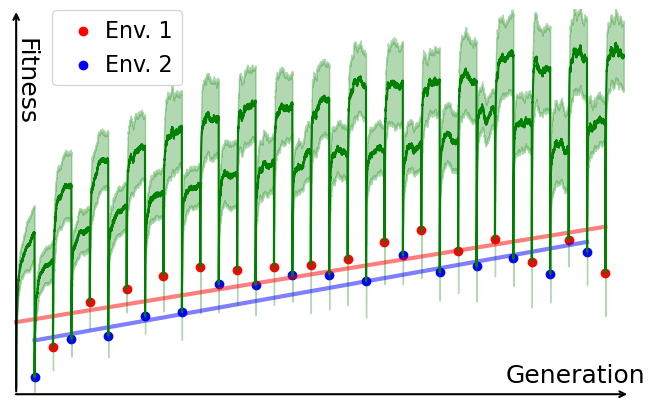

In [31]:
#Example line plot to illustrate methods

seed_intss = [[69904,149796],[4147842,1238860],[1677032,1410667],[2607162,1754028],[286634,159689],[2961036,153075],[3430997,2634107]]
metric="avefits"
season_len = 300
num_reps=15
root="~/CA_GRN_results/detailed_save/"#extra_inputs/"
root="~/CA_GRN_results/non_detailed_save/"#extra_inputs/"
id_start=0
seed_ints = seed_intss[1]

num_gens = 10_000

rules = [30] #[22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]

my_type = "mins" #"mins" or "drops" depending on which figure you want to make

s1drops=[]
s2drops=[]
fitdeltas1=[]
fitdeltas2=[]
for rule in rules:
    fig, ax=plt.subplots(nrows=1,ncols=1, figsize=(8, 5),sharex=True) #sharey=True)
    all_maxs=helper.get_fits([rule,rule], seed_ints, metric, root, season_len, num_reps, id_start, extrapolate=True)
    all_maxs=np.array(all_maxs)

    labels=["Variable","Static 1","Static 2"]
    colors = ["green", "lightblue", "orange"]
    z_value = 1.96  # For a 95% confidence interval

    m=all_maxs[0]
    mean1 = np.mean(m, axis=0)

    # HOW MUCH THEY DROP?
    season_starts1 = mean1[::300][1:][1::2]
    season_starts2 = mean1[::300][1:][::2]
    
    if my_type == "mins":
        xs = np.array(list(range(0,num_gens))[::300][1:-1][1::2])
        ys = season_starts1
        plt.scatter(xs, ys, color="red", label = "Env. 1")

        xs = np.concatenate([np.array([0]), xs])
        ys = np.concatenate([np.array([mean1[0]]), ys])
        slope, y_clip = np.polyfit(xs, ys, 1) 
        plt.plot(xs, slope*xs + y_clip, color='red', lw = 3, alpha=0.5)

        xs = np.array(list(range(0,num_gens))[::300][1:-1][::2])
        ys = season_starts2
        plt.scatter(xs, ys, color="blue", label = "Env. 2")

        #xs = np.concatenate([np.array([0]), xs])
        #ys = np.concatenate([np.array([mean1[0]]), ys])
        slope, y_clip = np.polyfit(xs, ys, 1) 
        plt.plot(xs, slope*xs + y_clip, color='blue', lw = 3, alpha=0.5)

        
    s1drops.append(season_starts1)
    s2drops.append(season_starts2)

    # HOW MUCH FITNESS DROPS
    s1_x_gens_late_idx = np.arange(0,9899)[300::300][1::2] - 1
    s2_x_gens_late_idx = np.arange(0,9899)[300::300][::2] - 1
    fit_delta1 = mean1[s1_x_gens_late_idx] - season_starts1
    fit_delta2 = mean1[s2_x_gens_late_idx] - season_starts2   
    #plt.scatter(s1_x_gens_late_idx, mean1[s1_x_gens_late_idx], color="blue",alpha=0.5)
    #plt.scatter(s2_x_gens_late_idx, mean1[s2_x_gens_late_idx], color="red",alpha=0.5)
    fitdeltas1.append(fit_delta1)
    fitdeltas2.append(fit_delta2)
    
    #The line itself
    stderr1 = np.std(m, axis=0) / np.sqrt(num_reps)
    ci_upper = mean1 + z_value * stderr1
    ci_lower = mean1 - z_value * stderr1
    ax.fill_between(range(len(mean1)), ci_lower, ci_upper, alpha=0.3,color=colors[0])
    ax.plot(mean1, "-", color=colors[0])
    ax.set_xlim(-100,num_gens)
    #plt.axvline(10_000)

    m_s1=all_maxs[1]
    means2 = np.mean(m_s1, axis=0)
    #ax.plot(means2, "-", color="red")

    m_s2=all_maxs[2]
    means3 = np.mean(m_s2, axis=0)
    #ax.plot(means3, "-", color="blue")


    def format_yticks(tick, _):
        return f"{tick:.2f}"

    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_yticks))
    
    # Get the current axis
    ax = plt.gca()

    # Remove standard spines
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

    # Remove ticks
    plt.xticks([])
    plt.yticks([])

    # Draw x and y arrows
    # x-axis arrow
    lower_y=0.5
    higer_y=0.65
    plt.ylim(lower_y,higer_y) #plt.ylim(0.5,0.65)
    plt.annotate('', xy=(1, lower_y), xytext=(0.005, lower_y),
                xycoords=('axes fraction', 'data'), textcoords=('axes fraction', 'data'),
                arrowprops=dict(arrowstyle='->', linewidth=1.5, color='black'))

    # y-axis arrow
    plt.annotate('', xy=(0.5, 1), xytext=(0.5, 0),
                xycoords=('data', 'axes fraction'), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', linewidth=1.5, color='black'))

    plt.text(0.8, 0.05, 'Generation', transform=ax.transAxes,
            ha='left', va='center', fontsize=18)

    # Add custom "y" label
    plt.text(0.025, 0.7, 'Fitness', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=18, rotation=90+180)

    if my_type == "drops":
        
        x1, y1 = s2_x_gens_late_idx, mean1[s2_x_gens_late_idx]
        x2,y2 = list(range(0,num_gens))[::300][1:-1][::2], season_starts2 #list(range(0,num_gens))[::300][1:-1][1::2], season_starts1

        for i in range(len(x1)):
            plt.plot([x1[i], x2[i]], [y1[i], y2[i]], color='r', marker='o', alpha=0.5, linewidth=5, label="Env 1." if i == 0 else "_nolegend_")

        x1, y1 = s1_x_gens_late_idx, mean1[s1_x_gens_late_idx]
        x2, y2 = list(range(0,num_gens))[::300][1:-1][1::2], season_starts1
        
        for i in range(len(x1)):
            plt.plot([x1[i], x2[i]], [y1[i], y2[i]], color='b', marker='o', alpha=0.5, linewidth=5, label="Env 2." if i == 0 else "_nolegend_")            

    plt.legend(loc='center left', bbox_to_anchor=(0.05, 0.9), fontsize=16,handletextpad=0)
    
    #plt.show()
    plt.savefig('figs/fig3CD_inset1.pdf', format='pdf', bbox_inches="tight")



    

In [ ]:
#Calculate values for all experiments
#Rerun for maxfits

seed_intss = [[69904,149796],[4147842,1238860],[1677032,1410667],[2607162,1754028],[286634,159689],[2961036,153075],[3430997,2634107]]
metric="avefits"
season_len = 300
num_reps=15
root="~/CA_GRN_results/detailed_save/"#extra_inputs/"
id_start=0
seed_ints = seed_intss[0]

rules = [22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]

s1drops=[]
s2drops=[]
fitdeltas1=[]
fitdeltas2=[]

c=0
for si in seed_intss:
    if c==0:
        myroot=root
    elif c==1:
        myroot="~/CA_GRN_results/non_detailed_save/"#extra_inputs/"
    else:
        myroot="~/CA_GRN_results/non_detailed_save/extra_inputs/"
    c+=1
    for rule in tqdm(rules):
        #fig, ax=plt.subplots(nrows=1,ncols=1, figsize=(10, 5),sharex=True) #sharey=True)
        all_maxs=helper.get_fits([rule,rule], si, metric, myroot, season_len, num_reps, id_start, extrapolate=True)
        all_maxs=np.array(all_maxs)

        m=all_maxs[0]
        mean1 = np.mean(m, axis=0)

        # HOW MUCH THEY DROP?
        season_starts1 = mean1[::300][1:][1::2]
        season_starts2 = mean1[::300][1:][::2]
        
        s1drops.append(season_starts1)
        s2drops.append(season_starts2)

        # HOW MUCH FITNESS CHANGES?
        s1_x_gens_late_idx = np.arange(0,9899)[300::300][1::2] -1
        s2_x_gens_late_idx = np.arange(0,9899)[300::300][::2] -1
        fit_delta1 = mean1[s1_x_gens_late_idx] - season_starts1
        fit_delta2 = mean1[s2_x_gens_late_idx] - season_starts2   
        fitdeltas1.append(fit_delta1)
        fitdeltas2.append(fit_delta2)
        
    

In [ ]:
all_exp_drop1=[]
all_exp_drop2=[]
all_exp_delta1=[]
all_exp_delta2=[]

def get_slopes(xs):
    outs=[]
    for i in range(105):
        xs[i] = [299 if j is None else j for j in xs[i]]
        slope, intercept = np.polyfit(np.arange(0,len(xs[i])), xs[i], 1)
        outs.append(slope)
    return outs


labels=[str(rule)+str(init) for rule, init in zip(np.array(seed_intss).repeat(len(rules),axis=0),rules * len(seed_intss)) ]

x=get_slopes(s1drops)
y=get_slopes(s2drops)

all_exp_drop1.append(x)
all_exp_drop2.append(y)

x=get_slopes(fitdeltas1)
y=get_slopes(fitdeltas2)

all_exp_delta1.append(x)
all_exp_delta2.append(y)

In [3]:
# load data from code above. 
# it takes a while to run above code so I saved it into a pickle file for quick reloading for plotting and further analysis.
with open(os.path.expanduser('~/CA_GRN_results/evolv_measures2.pkl'), 'rb') as f:
    loaded_data = pickle.load(f)


all_exp_drop1 = loaded_data["drops1"]
all_exp_drop2 = loaded_data["drops2"]
all_exp_delta1 = loaded_data["delta1"]
all_exp_delta2 = loaded_data["delta2"]

In [4]:
seed_intss = [[69904,149796],[4147842,1238860],[1677032,1410667],[2607162,1754028],[286634,159689],[2961036,153075],[3430997,2634107]]
rules = [22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]
labels=[str(rule)+str(init) for rule, init in zip(np.array(seed_intss).repeat(len(rules),axis=0),rules * len(seed_intss)) ]

/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as

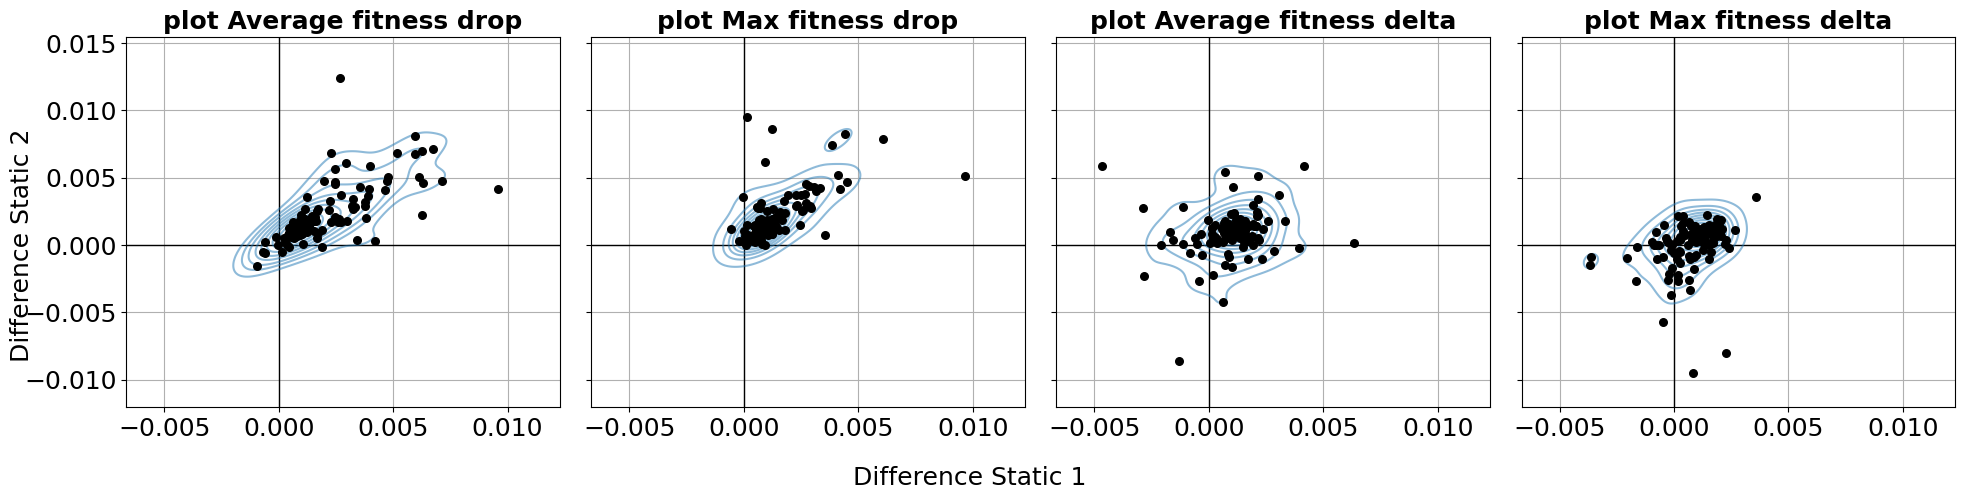

In [5]:
# Main figure and subplots
#fig, axs = plt.subplots(figsize=(6, 12), ncols=2, nrows = 2, sharex=True, sharey=True)
#axs = axs.flatten()

nrows,ncols = 1,4
scale = 5
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*scale, nrows*scale), sharex="row", sharey="row")
axs = axs.flatten()

titles=["Average fitness drop", "Max fitness drop","Average fitness delta", "Max fitness delta" ]

# Add lines to subplots
for idx,ax in enumerate(axs):
    ax.axvline(0, lw=1, color="black", zorder=1, alpha=1)
    ax.axhline(0, lw=1, color="black", zorder=1, alpha=1)

    if idx < 2:

        sns.kdeplot(x = all_exp_drop1[idx], y = all_exp_drop2[idx], ax=ax,fill=False,thresh=0.1,zorder=1,alpha=0.5)
        ax.scatter(all_exp_drop1[idx],all_exp_drop2[idx],marker="o", color="black", s=30)

    else:

        sns.kdeplot(x = all_exp_delta1[idx-2], y = all_exp_delta2[idx-2], ax=ax,fill=False,thresh=0.1,zorder=1,alpha=0.5)
        ax.scatter(all_exp_delta1[idx-2],all_exp_delta2[idx-2],marker="o", color="black", s=30)


    ax.set_title(f"plot {titles[idx]}", weight="bold", fontsize=18)

    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.grid()
    ax.set_axisbelow(True)


# Axis labels and titles
fig.supxlabel('Difference Static 1', fontsize = 18)
fig.supylabel('Difference Static 2', fontsize = 18)


#ax0.set_title("Maximum Fitness", weight="bold", fontsize=18)
#ax1.set_title("Average Fitness", weight="bold", fontsize=18)

plt.tight_layout()

#plt.show()
#plt.savefig('main_scatters.svg', format='svg')
plt.style.use('default')

/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'c'
  cset = contour_func(
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operat

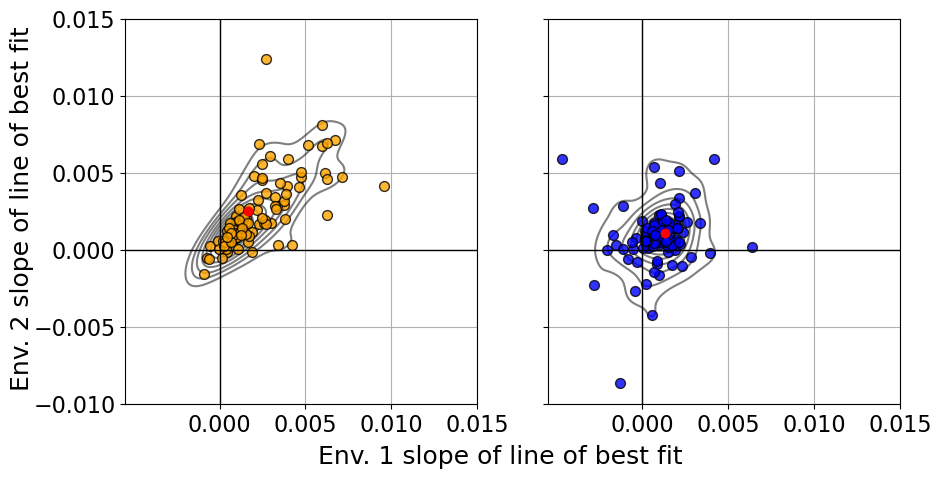

In [6]:
# Main figure and subplots

nrows,ncols = 1,2
scale = 5
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*scale, nrows*scale), sharex="row", sharey="row")
axs = axs.flatten()

titles=["Average fitness drop", "Max fitness drop","Average fitness delta", "Max fitness delta" ]

# Add lines to subplots
sns.kdeplot(x = all_exp_drop1[0], y = all_exp_drop2[0], ax=axs[0],fill=False,thresh=0.1,zorder=1,alpha=0.5,c="black")
axs[0].scatter(all_exp_drop1[0],all_exp_drop2[0],marker="o", color="orange", s=50,edgecolor="black", alpha=0.8)
for xi, yi, label in zip(all_exp_drop1[0], all_exp_drop2[0], labels):
    if "[4147842 1238860]30" in label: 
        axs[0].scatter(xi, yi, color="red")

sns.kdeplot(x = all_exp_delta1[0], y = all_exp_delta2[0], ax=axs[1],fill=False,thresh=0.1,zorder=1,alpha=0.5,c="black")
axs[1].scatter(all_exp_delta1[0],all_exp_delta2[0],marker="o", color="blue", s=50,edgecolor="black", alpha=0.8)
for xi, yi, label in zip(all_exp_delta1[0], all_exp_delta2[0], labels):
    if "[4147842 1238860]30" in label: #4147842,1238860
        #axs[0].text(xi, yi, label, fontsize=12, ha='right', va='bottom')
        axs[1].scatter(xi, yi, color="red")

for ax in axs:
    ax.axvline(0, lw=1, color="black", zorder=1, alpha=1)
    ax.axhline(0, lw=1, color="black", zorder=1, alpha=1)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.grid()
    ax.set_axisbelow(True)

    ax.set_xlim(-0.0055, 0.015)
    ax.set_ylim(-0.01, 0.015)
    ax.set_xticks([0, 0.005, 0.01, 0.015])


# Axis labels and titles
fig.supxlabel('Env. 1 slope of line of best fit', fontsize = 18,y=-0.02)
fig.supylabel('Env. 2 slope of line of best fit', fontsize = 18,x=0.01)

plt.style.use('default')
plt.savefig('figs/fig3CD.pdf', format='pdf', bbox_inches="tight")

In [ ]:
#Doing statistics

seed_intss = [[69904,149796],[4147842,1238860],[1677032,1410667],[2607162,1754028],[286634,159689],[2961036,153075],[3430997,2634107]]
metric="avefits"
season_len = 300
num_reps=15
root="~/CA_GRN_results/detailed_save/"#extra_inputs/"
id_start=0
seed_ints = seed_intss[0]

rules = [22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]

s1drops=[]
s2drops=[]
fitdeltas1=[]
fitdeltas2=[]

c=0
for si in seed_intss:
    if c==0:
        myroot=root
    elif c==1:
        myroot="~/CA_GRN_results/non_detailed_save/"#extra_inputs/"
    else:
        myroot="~/CA_GRN_results/non_detailed_save/extra_inputs/"
    c+=1
    for rule in rules:
        #fig, ax=plt.subplots(nrows=1,ncols=1, figsize=(10, 5),sharex=True) #sharey=True)
        all_maxs=helper.get_fits([rule,rule], si, metric, myroot, season_len, num_reps, id_start, extrapolate=True)
        all_maxs=np.array(all_maxs)
        labels=["Variable","Static 1","Static 2"]
        colors = ["green", "lightblue", "orange"]
        z_value = 1.96  # For a 95% confidence interval

        m=all_maxs[0]
        mean1 = m.copy() #np.mean(m, axis=0)

        # HOW MUCH THEY DROP?
        season_starts1 = mean1[:,::300][:,1:][:,1::2]
        season_starts2 = mean1[:,::300][:,1:][:,::2]
        
        s1drops.append(season_starts1)
        s2drops.append(season_starts2)

        # HOW MUCH FITNESS CHANGES
        s1_x_gens_late_idx = np.arange(0,9899)[300::300][1::2] -1
        s2_x_gens_late_idx = np.arange(0,9899)[300::300][::2] -1
        fit_delta1 = mean1[:,s1_x_gens_late_idx] - season_starts1
        fit_delta2 = mean1[:,s2_x_gens_late_idx] - season_starts2 
        
        fitdeltas1.append(fit_delta1)
        fitdeltas2.append(fit_delta2)


In [15]:
def get_slopes(xs):
    outs=[]
    for i in range(105):
        slope, intercept = np.polyfit(np.arange(0,len(xs[i])), xs[i], 1)
        outs.append(slope)
    return outs


labels=[str(rule)+str(init) for rule, init in zip(np.array(seed_intss).repeat(len(rules),axis=0),rules * len(seed_intss)) ]

dropx=get_slopes(np.array(s1drops).mean(axis=1))
dropy=get_slopes(np.array(s2drops).mean(axis=1))

fdx=get_slopes(np.array(fitdeltas1).mean(axis=1))
fdy=get_slopes(np.array(fitdeltas2).mean(axis=1))

In [ ]:
s1drops = np.array(s1drops)
s2drops = np.array(s2drops)
fitdeltas1 = np.array(fitdeltas1)
fitdeltas2 = np.array(fitdeltas2)

signs=[]
for t in [s1drops, s2drops, fitdeltas1, fitdeltas2]:
    pdic = []
    for r in range(105):
        curr_rule = t[r, :, :]
        slopes = []
        for rep in range(15):
            ys = curr_rule[rep, :]
            xs = np.arange(len(ys))
            slope, intercept, r_value, p_value, std_err = stats.linregress(xs, ys)
            slopes.append(slope)
        slopes = np.array(slopes)
        # Now test if the average slope is significantly greater than zero
        #This is a test for the null hypothesis that the expected value (mean) of a sample of 
        # independent observations _slopes_ is equal to the given number, 0.
        t_stat, p_val = stats.ttest_1samp(slopes, 0)

        pdic.append(p_val)
    fdr = multipletests(np.array(pdic), method='fdr_bh')[1]

    signs.append(np.where(fdr<0.05)[0])

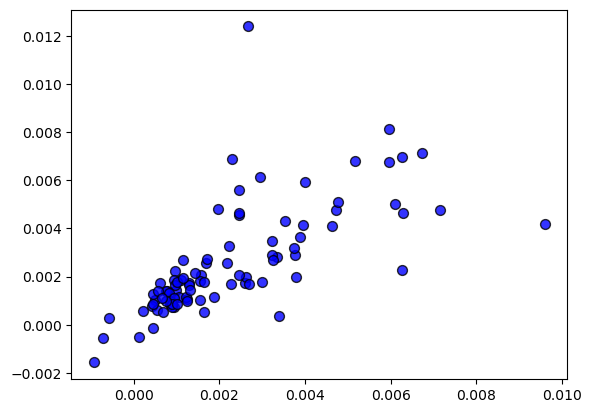

In [19]:
drops_sign=np.concatenate([signs[0],signs[1]])
drops_sign=np.unique(drops_sign)

plt.scatter(np.array(dropx)[drops_sign],np.array(dropy)[drops_sign],marker="o", color="blue", s=50,edgecolor="black", alpha=0.8)

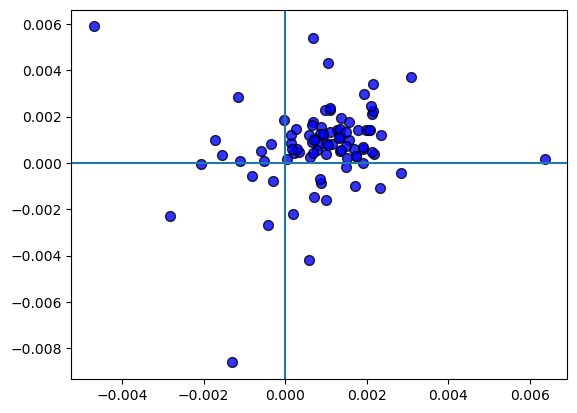

In [20]:
fd_sign=np.concatenate([signs[2],signs[3]])
fd_sign=np.unique(drops_sign)

plt.scatter(np.array(fdx)[fd_sign],np.array(fdy)[fd_sign],marker="o", color="blue", s=50,edgecolor="black", alpha=0.8)
plt.axvline(0)
plt.axhline(0)